# Notebook : Prétraitement des données EEG

**Objectif :** Explorer les données au format BIDS, appliquer un pipeline de nettoyage complet et factoriser le flux de travail en fonctions réutilisables.

### Version 2

Il s'agit de la deuxième version de ce notebook. Elle inclut quelques modifications et correctifs pour résoudre des erreurs mineures. Le flux de travail général reste identique à la version précédente.

### Remarque importante

La démarche de ce notebook consiste d'abord à explorer et tester le code **individuellement sur un seul sujet**.

Une fois les étapes validées, une **fonction finale** regroupe tous les blocs de code. Cette fonction permet d'appliquer l'ensemble du pipeline de traitement à **tous les sujets** de manière automatisée.

> **Attention :** Si vous avez expérimenté avec différents paramètres (par exemple, des seuils de filtrage ou des critères de rejet) et que vous souhaitez utiliser des valeurs autres que celles définies par défaut, **ou si vous avez ajouté d'autres blocs de code ou de nouvelles méthodes**, n'oubliez pas de **mettre à jour la fonction finale** en conséquence avant de l'exécuter sur l'ensemble des données.

### Contexte et références

Ce notebook prolonge le mobilise des notions introduites dans :
- Module 0 — gestion de l'environnement (fichiers, `conda`, `pip`)
- Module 3 — manipulation Python adaptée aux données M/EEG
- Module 4 — chargement et inspection des données MNE
- Module 5 — prétraitement (filtrage, AutoReject, ICA)

Chaque section annonce le type de bloc :
- **Type 1** : méthode de base prête à exécuter
- **Type 2** : bloc à compléter / faire des ajustements
- **Type 3** : exploration optionnelle/ouverte

> Informations: les données sont organisées en BIDS. Consultez la documentation [MNE-BIDS](https://mne.tools/mne-bids/stable/index.html) pour plus de détails.

Instructions pratiques — préparation des données et de l'environnement
- Téléchargez les données depuis le lien fourni (voir consigne du cours) et placez le dossier nommé `tasks` au même niveau que ce notebook (même dossier parent). Exemple de structure attendue :
    - project_folder/
        - 01_preprocessing_notebook.ipynb
        - tasks/

N'oublier pas de créer et activer un environnement virtuel (local / VSCode) comme vue deja en cours (Module 0 et 2 pour reference)
Pour ceux qui utilise VSCode : sélectionnez l'interpréteur du venv via "Python: Select Interpreter". 

Si vous travaillez sur Colab
- Soit téléversez le dossier `tasks` via l'interface "Files" de Colab,
- soit montez Google Drive et copiez le dossier :
    ```python
    from google.colab import drive
    drive.mount('/content/drive')
    # puis copier / lier votre dossier tasks dans /content
    ```

Installer les dépendances requises
- Exemple de commande pour installer les librairies utilisées dans ce notebook :
    ```
    pip install mne mne-bids autoreject mne-icalabel matplotlib pandas numpy
    ```
- Alternative : placez ces lignes dans un `requirements.txt` et lancez `pip install -r requirements.txt`.
- Remarque : dans un notebook, préférez `!pip install ...` pour vous assurer que l'installation cible l'interpréteur du kernel courant.

Vérification finale
- Après activation / sélection du kernel, exécutez une cellule courte pour confirmer les imports :
    ```python
    import mne, mne_bids, autoreject, mne_icalabel, numpy, pandas, matplotlib, torch
    print('OK')
    ```
- Lancez ensuite la cellule qui définit `root_bids` et vérifiez que `tasks` (ou le dataset) est détecté.

### Instructions pour exécuter ce notebook

- Si vous n'avez pas encore cloné le dépôt du cours (PSY2007D2025-Cours-UdeM), ouvrez un terminal et collez/exécutez la commande suivante :
    ```bash  
    git clone https://github.com/BabaSanfour/PSY2007D2025-Cours-UdeM
    ```

- Si vous avez déjà cloné le repo et voulez récupérer les dernières modifications :
    ```bash
    cd PSY2007D2025
    git pull
    ```

- Si vous préférez une interface graphique :
  - GitHub Desktop : File → Clone repository → entrez l'URL.
  - VSCode : View → SCM → Clone Repository, ou utilisez l'icône Source Control.
  - Sur GitHub web : Code → Download ZIP (dézippez ensuite localement).

- Pire des cas — pas d'accès à git : copiez le notebook cellule par cellule dans un nouveau notebook vide.

Cloner et ouvrir directement dans Colab
- Clonage simple depuis Colab (dans une cellule) :
    ```bash
    !git clone https://github.com/BabaSanfour/PSY2007D2025-Cours-UdeM
    !ls -la
    ```

Conseil important — travaillez sur une copie
- Avant de modifier ce notebook partagé, créez et travaillez sur une copie :
  - Jupyter Notebook : File → Make a Copy... → renommez en `01_preprocessing_notebook_COPIE.ipynb`
  - Colab : File → Save a copy in Drive → renommez en `01_preprocessing_notebook_COPIE.ipynb`
- Travailler sur une copie évite d'écraser l'original et facilite les comparaisons / pull requests.

## 1. Explorer et visualiser les fichiers BIDS

Objectifs : comprendre la structure du dossier, charger un enregistrement et inspecter le signal brut.

### Bloc Type 1 — Méthode de base
Initialisation des bibliothèques et paramètres globaux (chemins BIDS, fréquence secteur, configuration graphique).

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from autoreject import AutoReject
from mne.preprocessing import ICA
from mne_bids import BIDSPath, read_raw_bids
from mne_icalabel.iclabel import iclabel_label_components

warnings.filterwarnings('ignore', category=RuntimeWarning)
mne.set_log_level('INFO')

# Renseignez ici la racine du dossier BIDS a utiliser
#exp tasks/fivepoint/bids/
root_bids = Path('tasks/fivepoint/bids/')
if not root_bids.exists():
    print('Attention: le dossier BIDS indique est introuvable. Mettez a jour `root_bids`.')
else:
    print('Dossier BIDS detecte:', root_bids.resolve())


Dossier BIDS detecte: /Users/hamzaabdelhedi/Projects/Tutorials/PSY2007A2025/tasks/fivepoint/bids


### Bloc Type 2 — À vous de compléter
Énumérez les sessions et fichiers disponibles. Inspirez-vous du Module 0 (parcours de dossiers) et de la méthode `BIDSPath`.

In [40]:
# Bloc Type 2 — À vous de jouer !
#
# La structure BIDS standardise les noms de fichiers.
# Pour lire un fichier d'un sujet spécifique avec BIDSPath, il suffit donc
# de définir les identifiants (sujet, session, etc.) à traiter.
#
# Dans ce jeu de données, nous n'avons qu'une seule session et un seul run.

# TODO : Renseignez la liste des sujets que vous souhaitez explorer.
# Astuce : Vous pouvez utiliser Path.glob ou BIDSPath pour lister 
# automatiquement les dossiers de la structure BIDS (ex: sub-*, ses-*).
# sinon, vous pouvez les voir manuellement dans le dossier tasks/fivepoint/bids/

subjects = ['01', '02'] # Liste des sujets à traiter. Ajoutez ou modifiez au besoin.
session = '001' # Identifiant de la session (une seule dans ce jeu de données).
task = 'fivepoint' # Tâche à analyser (à adapter selon le jeu de données).
run = '01' # Identifiant du run (un seul dans ce jeu de données).

print('Sujets à traiter :', subjects)
print('Session :', session)
print('Tâche :', task, 'Run :', run)

Sujets à traiter : ['01', '02']
Session : 001
Tâche : fivepoint Run : 01


### Bloc Type 1 — Méthode de base
Chargement d'un enregistrement brut via `read_raw_bids` et inspection des métadonnées principales.

In [41]:
# Lecture des données EEG du premier sujet de la liste
#
# Pour lire un autre sujet, il suffit de modifier l'index (ex: subjects[1]).
# Rappel : les index en Python commencent à 0.

bids_path = BIDSPath(root=root_bids,
                    subject=subjects[0], # Sélectionne le premier sujet défini dans la liste.
                    session=session,
                    task=task,
                    run=run,
                    suffix='eeg',
                    extension='.vhdr')

print('Lecture du fichier :', bids_path.fpath)
raw = read_raw_bids(bids_path)
raw.load_data() # Charge les données en mémoire pour le traitement
print('Données chargées avec succès.')
raw.info

Lecture du fichier : tasks/fivepoint/bids/sub-01/ses-001/sub-01_ses-001_task-fivepoint_run-01_eeg.vhdr
Extracting parameters from tasks/fivepoint/bids/sub-01/ses-001/eeg/sub-01_ses-001_task-fivepoint_run-01_eeg.vhdr...
Setting channel info structure...
Reading events from tasks/fivepoint/bids/sub-01/ses-001/eeg/sub-01_ses-001_task-fivepoint_run-01_events.tsv.
Reading channel info from tasks/fivepoint/bids/sub-01/ses-001/eeg/sub-01_ses-001_task-fivepoint_run-01_channels.tsv.
Reading 0 ... 149399  =      0.000 ...   497.997 secs...
Données chargées avec succès.


<Info | 11 non-empty values
 bads: []
 ch_names: P3, C3, F3, Fz, F4, C4, P4, Cz, CM, A1, Fp1, Fp2, T7, P7, O1, ...
 chs: 19 EEG, 7 misc, 1 Stimulus
 custom_ref_applied: False
 description: Anonymized using a time shift to preserve age at acquisition
 experimenter: mne_anonymize
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 150.0 Hz
 meas_date: 2025-10-09 09:34:12 UTC
 nchan: 27
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: sub-01, birthday: 1999-10-09, sex: 1, hand: 0>
>

In [42]:
# Les données ont été reférencées en utilisant le canal 'Pz' comme référence.
#
# Le référencement est une étape importante en EEG. Il consiste à prendre en compte
# que les potentiels mesurés sont relatifs à un point de référence commun.
#
# Pour éviter que ce canal de référence ('Pz') ne soit inclus par erreur
# dans les analyses EEG ultérieures (ex: ICA), nous changeons son type en 'misc'.
raw.set_channel_types({'Pz': 'misc'})


# --- ALTERNATIVE (v1) ---
# On pourrait aussi le supprimer complètement.
# Pour cela, décommentez les lignes suivantes :

# Supprimer le canal 'Pz' (s'il est présent)
# if 'Pz' in raw.ch_names:
#     raw.drop_channels(['Pz'])
#     print("Canal 'Pz' supprimé de `raw`.")
# else:
#     print("Canal 'Pz' absent — rien à faire.")

# # Mettre à jour la sélection de canaux si nécessaire
# if 'canaux' in globals():
#     canaux = [ch for ch in canaux if ch != 'Pz']
#     print('Liste `canaux` mise à jour :', canaux)

<RawBrainVision | sub-01_ses-001_task-fivepoint_run-01_eeg.eeg, 27 x 149400 (498.0 s), ~30.8 MiB, data loaded>

In [43]:
# Ici, on ajoute le digitizer pour les positions 3D des électrodes.
# Cela peut être utile pour certaines analyses (ex: plot_topomap).
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)
print('Montage 10-20 standard appliqué.')

Montage 10-20 standard appliqué.


### Bloc Type 2 — À vous de compléter
Choisissez les canaux à afficher et ajustez la durée/offset d'affichage (`raw.plot`). Révisez les notions du Module 4.

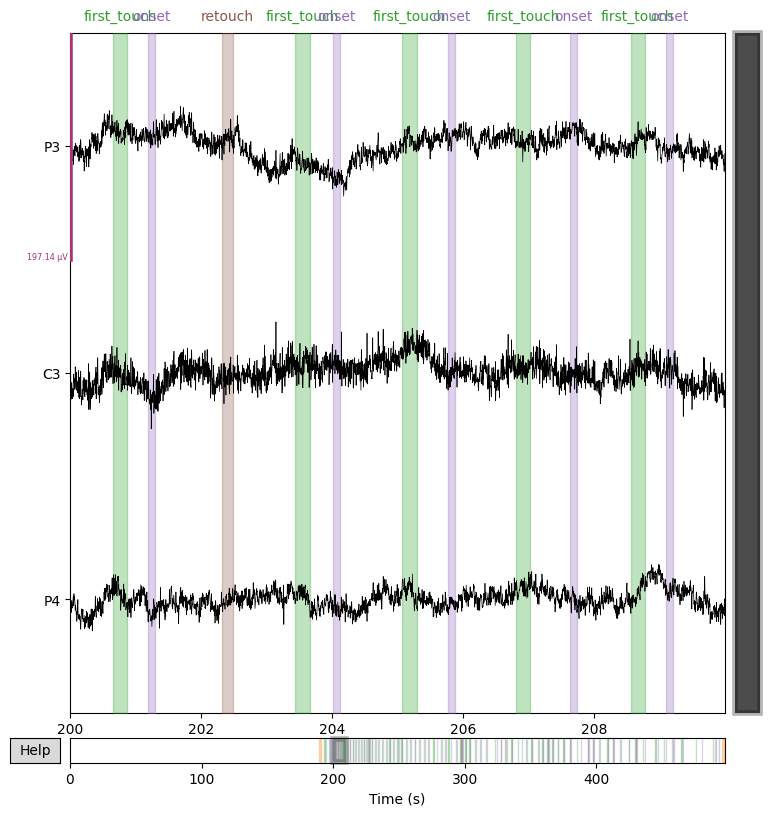

In [44]:
# TODO: parametrez les canaux et la duree de visualisation
canaux = ['P3', 'C3', 'P4']  # remplacez par une selection pertinente, raw.chn_names peut aider
duree = 10        # ex. 30, 60 ... (secondes)
debut = 200        # ex. 0 ou 60

fig = raw.plot(picks=canaux, duration=float(duree), start=float(debut),
               scalings='auto', title='Signal brut Mario', show=False)
plt.show()


### Bloc Type 3 — Pour aller plus loin
Comparez rapidement PSD ou topographies de bruit pour comprendre la qualité du signal. Appuyez-vous sur le Module 6.

Effective window size : 6.827 (s)
Plotting power spectral density (dB=True).


/Users/hamzaabdelhedi/Projects/Tutorials/PSY2007A2025/.venv_psy2007/lib/python3.10/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


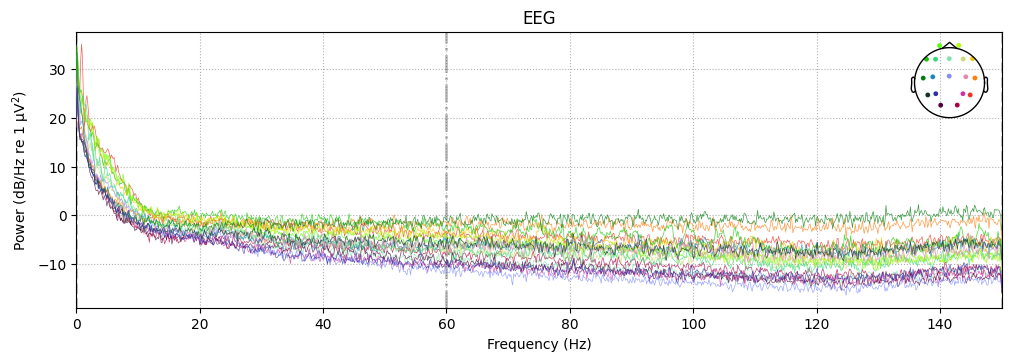

In [45]:
raw.compute_psd(picks='eeg').plot()
# en utilisant la documentation de MNE, essayez de personnaliser le tracé (ex. fmin, fmax, etc.)

## 2. Pipeline complet de nettoyage et de prétraitement

Objectifs : filtrage, AutoReject, ICA, ICLabel, deuxième passe et préparer les données pour des analyses ultérieures.

### Étape 2.1 — Filtrage
Nous appliquons un filtre notch et un bandpass.

#### Bloc Type 1 — Méthode de base
Application des paramètres standards (60 Hz, 1-40 Hz).

In [46]:
# Ici, nous appliquons un filtre notch et un bandpass.
# Le filtre notch est utilisé pour éliminer les interférences à 60 Hz (fréquence du courant électrique).
# Le filtre passe-bande (bandpass) permet de ne conserver que les fréquences d'intérêt entre 1 et 40 Hz.
raw_filt = raw.copy()
raw_filt.notch_filter(freqs=[60])
raw_filt.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin')
print('Filtrage')

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1981 samples (6.603 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge

#### Bloc Type 2 — À vous de compléter

Adaptez le filtrage et jouez avec les différents paramètres.

Consultez la documentation MNE pour plus de détails sur les fonctions :

`Raw.filter` (pour le filtrage passe-bande)

`Raw.notch_filter` (pour supprimer la contamination du secteur, ex: 60 Hz)

In [47]:
# TODO : Personnalisez les paramètres de filtrage ci-dessous.
#
# Rappel : Si vous décidez de modifier ces filtres, assurez-vous d'utiliser
# l'objet `raw_custom` (et non `raw`) pour tous les traitements suivants.

# ---
# ATTENTION : N'oubliez pas de reporter ces mêmes paramètres
# dans la fonction finale qui regroupe toutes les méthodes et
# les applique à l'ensemble des sujets !
# ---

frequences_notch = [60, 120] # Fréquences à supprimer (filtre notch), ex: [60]
l_freq = 0.5 # Fréquence de coupure basse (filtre passe-haut)
h_freq = 45 # Fréquence de coupure haute (filtre passe-bas)

# Création d'une copie pour tester les filtres
raw_custom = raw.copy()

# 1. Appliquer le filtre notch
raw_custom.notch_filter(freqs=[float(f) for f in frequences_notch])

# 2. Appliquer le filtre passe-bande
raw_custom.filter(l_freq=float(l_freq), h_freq=float(h_freq), fir_design='firwin')

# Afficher les informations de l'objet filtré
raw_custom

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1981 samples (6.603 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1981 samples (6.603 s)



<RawBrainVision | sub-01_ses-001_task-fivepoint_run-01_eeg.eeg, 27 x 149400 (498.0 s), ~30.8 MiB, data loaded>

#### Bloc Type 3 — Pour aller plus loin
Visualisez l'impact du filtrage via des figures avant/après (traces, PSD, topomaps).

Effective window size : 6.827 (s)
Plotting power spectral density (dB=True).


/Users/hamzaabdelhedi/Projects/Tutorials/PSY2007A2025/.venv_psy2007/lib/python3.10/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


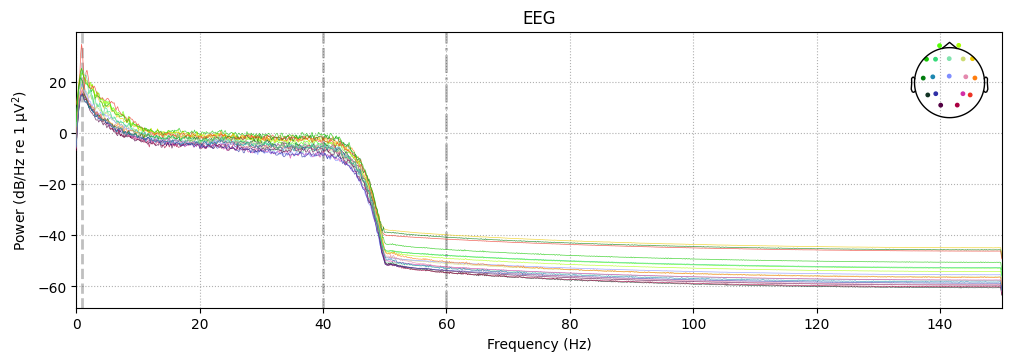

In [48]:
raw_filt.compute_psd(picks='eeg').plot()

Effective window size : 6.827 (s)
Plotting power spectral density (dB=True).


/Users/hamzaabdelhedi/Projects/Tutorials/PSY2007A2025/.venv_psy2007/lib/python3.10/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


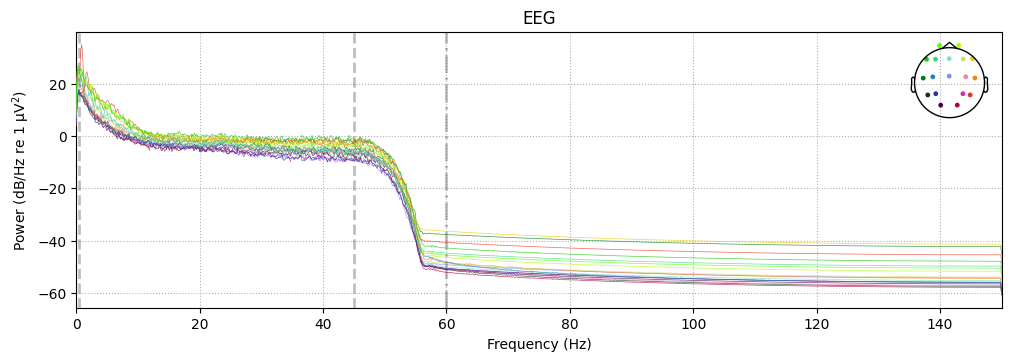

In [49]:
raw_custom.compute_psd(picks='eeg').plot()

Effective window size : 6.827 (s)


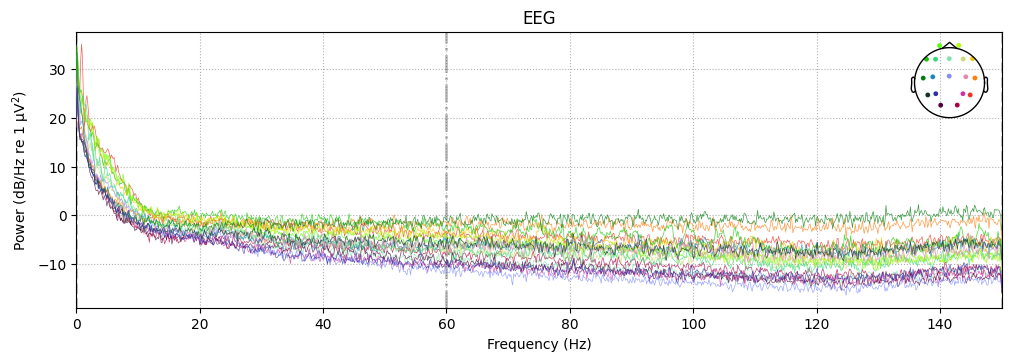

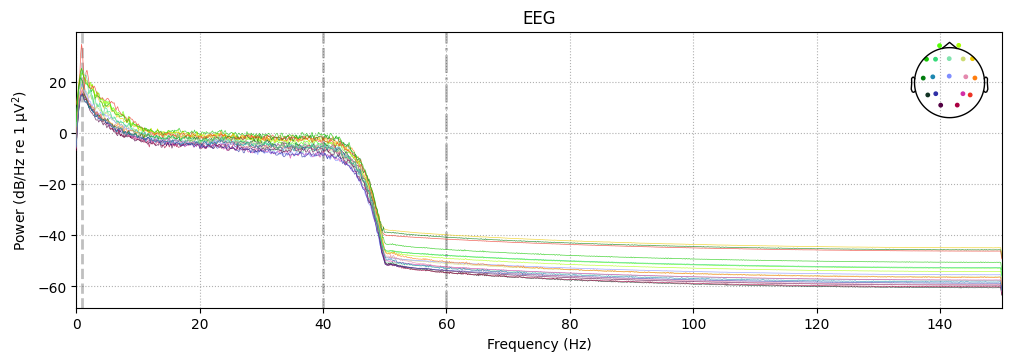

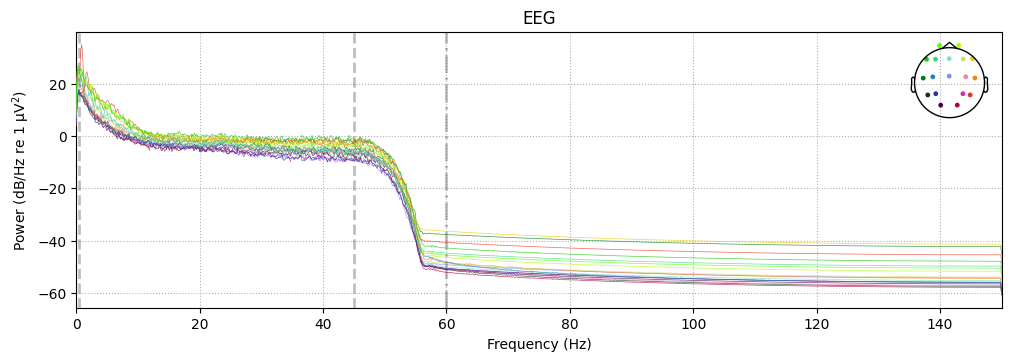

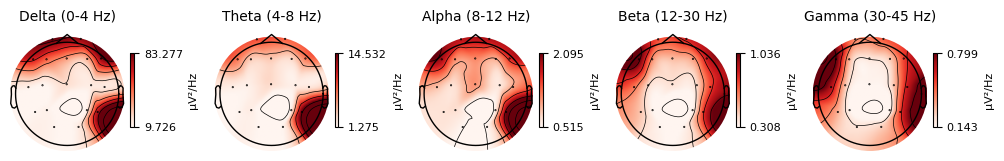

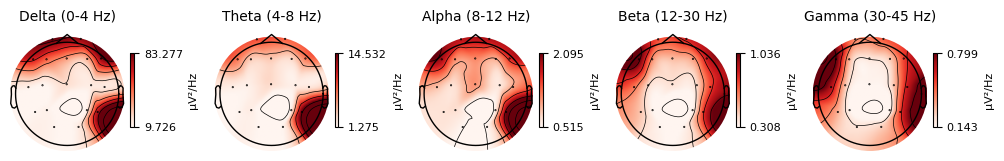

In [50]:
raw_custom.compute_psd(picks='eeg').plot_topomap(ch_type="eeg", agg_fun=np.median)

### Étape 2.2 — Détection automatique des artéfacts (AutoReject)
Nous utilisons AutoReject pour rejeter ou réparer les epochs bruitées.

#### Bloc Type 1 — Méthode de base
Création d'epochs basées sur les annotations BIDS (`events.tsv`) et exécution d'AutoReject avec paramètres par défaut.

In [90]:
# --- 1. Appliquer le montage (Positions des électrodes) ---
# Le montage contient les coordonnées 3D des électrodes.
# C'est essentiel pour toute topographie (visualisation spatiale)
# et pour certains algorithmes qui dépendent de la localisation (ex: ICA).
montage_1020 = mne.channels.make_standard_montage('standard_1020')

# On applique le montage à nos données.
# on_missing='warn' : MNE nous avertira si des canaux de nos données
# (ex: 'Pz' que nous avons mis en 'misc') ne sont pas dans le montage
# standard, mais il ne plantera pas.
raw_filt.set_montage(montage_1020, on_missing='warn')
print("Montage 10-20 appliqué (on_missing='warn').")

# --- 2. Extraction des Événements (Events) ---
# Les 'annotations' (textes et temps) dans le 'raw' sont converties
# en un tableau d'événements (matrice numpy) que MNE peut utiliser
# pour le découpage (epoching).
events, event_id = mne.events_from_annotations(raw_filt)
print(f"Nombre d'événements détectés : {len(events)}")

# --- 3. Découpage (Epoching) ---
# Nous coupons le signal continu en 'epochs' (périodes)
# centrées sur chaque événement.
epochs = mne.make_fixed_length_epochs(raw_filt, duration=2.0, 
                                      overlap=0.0, preload=True)

print(epochs)

# --- 4. Préparation pour AutoReject ---

# Conserver une copie du signal filtré avant l'ICA
# C'est une bonne pratique. Si l'ICA est calculée sur les epochs,
# on peut vouloir appliquer la solution ICA sur ce 'raw' continu.
raw_pre_ica = raw_filt.copy()

# Astuce de notebook : réutilise l'objet 'auto_reject' s'il existe déjà
# (si on relance la cellule), sinon on en crée un nouveau.
# Évite de ré-entraîner (fit) inutilement.
auto_reject = globals().get('auto_reject', AutoReject(random_state=42, verbose='tqdm'))

# Entraînement (fit) : AutoReject apprend les seuils de rejet optimaux
# en analysant la statistique de toutes les epochs fournies.
auto_reject.fit(epochs)

# Applique les seuils appris pour créer un "log"
# (un rapport) des epochs qui sont jugées mauvaises.
reject_log = auto_reject.get_reject_log(epochs)

# --- 5. Nettoyage des Epochs ---
# reject_log.bad_epochs est un masque booléen [True, False, True, ...]
# où 'True' signifie 'MAUVAISE epoch'.
# Nous utilisons l'opérateur tilde '~' (NOT) pour inverser ce masque.
# good_mask sera donc [False, True, False, ...] où 'True' signifie 'BONNE epoch'.
good_mask = ~reject_log.bad_epochs
print(f"Total epochs: {len(epochs)}, rejetés par AutoReject: {reject_log.bad_epochs.sum()}")

# On sélectionne (slice) les epochs en utilisant notre masque 'good_mask'.
# .copy() est important pour créer un nouvel objet 'epochs'
# indépendant en mémoire.
epochs_clean = epochs[good_mask].copy()
print("Epochs après nettoyage par AutoReject :")
print(epochs_clean)

Montage 10-20 appliqué (on_missing='warn').
Used Annotations descriptions: [np.str_('END'), np.str_('START'), np.str_('first_touch'), np.str_('onset'), np.str_('retouch')]
Nombre d'événements détectés : 153
Not setting metadata
249 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 249 events and 600 original time points ...
0 bad epochs dropped
<Epochs | 249 events (all good), 0 – 1.997 s (baseline off), ~30.8 MiB, data loaded,
 '1': 249>
Running autoreject on ch_type=eeg


100%|██████████| Creating augmented epochs : 18/18 [00:00<00:00,  157.32it/s]
100%|██████████| Computing thresholds ... : 18/18 [00:13<00:00,    1.33it/s]























































































100%|██████████| Repairing epochs : 249/249 [00:01<00:00,  149.84it/s]





















































































100%|██████████| Repairing epochs : 249/249 [00:01<00:00,  127.11it/s]






















100%|██████████| Fold : 10/10 [00:01<00:00,    5.22it/s]





















































































100%|██████████| Repairing epochs : 249/249 [00:01<00:00,  137.05it/s]






















100%|██████████| Fold : 10/10 [00:01<00:00,    6.03it/s]























































































100%|██████████| Repairing epochs : 249/249 [00:01<00:00,  138.73it/s]






















100%|██████████| Fold : 10/10 [00:00<





Estimated consensus=1.00 and n_interpolate=17
Total epochs: 249, rejetés par AutoReject: 7
Epochs après nettoyage par AutoReject :
<Epochs | 242 events (all good), 0 – 1.997 s (baseline off), ~30.0 MiB, data loaded,
 '1': 242>


#### Bloc Type 2 — À vous de compléter
Ajustez les paramètres d'AutoReject (`cv`, `n_interpolate`, `consensus`) et la fenêtre temporelle. Voir Module 5 et la documentation AutoReject.

In [ ]:
# TODO : Affiner les hyperparamètres d'AutoReject
#
# Ce bloc est un "bac à sable" pour expérimenter avec des réglages
# plus fins pour AutoReject et même pour la fenêtre d'epoching.
#
# ---
# ATTENTION - Conséquences de vos tests :
#
# 1. MISE À JOUR DE LA FONCTION FINALE :
#    Si vous trouvez des paramètres (cv, n_interpolate, consensus, tmin, tmax)
#    qui fonctionnent mieux que ceux par défaut, vous DEVEZ les
#    reporter dans la fonction finale pour qu'ils s'appliquent à tous les sujets.
#
# 2. NOM DES VARIABLES :
#    Si vous souhaitez continuer le notebook en utilisant les résultats
#    de CE bloc (et non du bloc précédent), vous devrez utiliser
#    les nouvelles variables : `epochs_tuned_clean` et `reject_log_tuned`.
# ---

# --- 1. Paramètres à tester ---

# Validation croisée (k-fold) pour optimiser les seuils
cv = 'A_COMPLETER' # ex. 10 (un entier)

# Nombre de canaux à interpoler. AutoReject testera ces options.
n_interpolate = ['A_COMPLETER'] # ex. [1, 4, 8] (une liste d'entiers)

# Pourcentage de 'folds' qui doivent être d'accord pour rejeter une epoch
consensus = ['A_COMPLETER'] # ex. [0.8, 0.9] (une liste de floats)

# Vous pouvez aussi tester une fenêtre temporelle différente pour les epochs
Epoch_duration = 'A_COMPLETER' 

# --- 2. Garde-fou (Safety Check) ---
# Vérifie si toutes les valeurs 'A_COMPLETER' ont été modifiées
if 'A_COMPLETER' in [str(cv), str(tmin), str(tmax)] or 'A_COMPLETER' in [str(x) for x in n_interpolate] or 'A_COMPLETER' in [str(x) for x in consensus]:
    raise ValueError("Remplissez tous les paramètres ('A_COMPLETER') avant d'exécuter ce bloc.")

# --- 3. Création des nouvelles epochs (basées sur tmin/tmax) ---
print(f"Création de nouvelles epochs : tmin={tmin}, tmax={tmax}")
epochs = mne.make_fixed_length_epochs(raw_filt, duration=2.0, 
                                      overlap=0.0, preload=True)

# --- 4. Instance et exécution d'AutoReject avec les nouveaux paramètres ---
auto_reject_tuned = AutoReject(cv=int(cv), n_interpolate=[int(x) for x in n_interpolate],
                               consensus=[float(x) for x in consensus], random_state=42, verbose='tqdm')

print("Lancement d'AutoReject avec les paramètres personnalisés...")
# fit_transform() entraîne (fit) ET applique (transform) le nettoyage
epochs_tuned_clean, reject_log_tuned = auto_reject_tuned.fit_transform(epochs_tuned, return_log=True)

# --- 5. Visualisation du résultat ---
print("Affichage du log de rejet (version personnalisée) :")
reject_log_tuned.plot('horizontal')

#### Bloc Type 3 — Pour aller plus loin
Analysez visuellement les epochs rejetées, comparez plusieurs configurations, documentez vos choix.

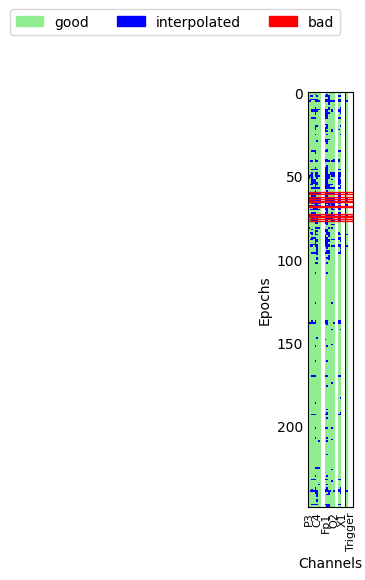

In [92]:
fig = reject_log.plot('vertical')
fig.suptitle('Suivi des rejets AutoReject (configuration de base)')
plt.show()


### Étape 2.3 — ICA + ICLabel
Objectifs : identifier les composantes artefact et les exclure du signal.

#### Bloc Type 1 — Méthode de base
ICA sur les epochs nettoyées, application d'ICLabel et exclusion automatique des composantes oeil/muscle.

In [93]:
# --- 1. Installation (si nécessaire) ---
# Ce bloc nécessite la bibliothèque mne_iclabel.
# Décommentez la ligne suivante pour l'installer si ce n'est pas déjà fait.
# !pip install mne_iclabel

# --- 2. Initialisation et Fit de l'ICA ---
# Nous entraînons l'algorithme ICA.
# n_components=18 : nombre de composantes à estimer.
#                  (C'est un hyperparamètre à ajuster !)
# random_state=97 : assure la reproductibilité des résultats.
#
# On entraîne (fit) l'ICA uniquement sur les epochs propres (epochs_clean)
# déterminées par AutoReject. C'est une bonne pratique.
ica = ICA(n_components=18, method='fastica', random_state=97)
ica.fit(epochs_clean)

# --- 3. Classification des composantes avec ICLabel ---
# Nous utilisons ICLabel pour classifier automatiquement chaque
# composante ICA (ex: 'cerveau', 'oeil', 'muscle', etc.).
probabilities = iclabel_label_components(epochs_clean, ica)

# ERREUR CORRIGÉE :
# La variable 'classes' doit être définie.
classes = ['brain', 'muscle', 'eye', 'line_noise', 'channel_noise', 'other']

# --- 4. Identification des composantes oculaires ---

# TODO : Ajustez ce seuil au besoin.
# C'est le niveau de "confiance" requis pour marquer
# une composante comme étant "oculaire".
threshold_eye = 0.7

# Trouver l'index de la colonne 'eye'
index_eye = class_names.index('eye')
# Extraire les scores de probabilité pour 'eye' pour toutes les composantes
eye_scores = probas[:, index_eye]

eye_components = [idx for idx, score in enumerate(eye_scores) if score >= threshold_eye]

# Affichage des scores pour vérification
print('Scores ICLabel (oeil):')
for idx, (label, score) in enumerate(zip(classes, eye_scores)):
    print(f"  IC {idx:02d}: label={label:>15} score={score:.2f} {'<-- REJETÉ' if idx in eye_components else ''}")

print(f'\nComposantes oculaires retenues (seuil > {threshold_eye}):', eye_components)
ica.exclude = eye_components

# --- 5. Application de l'ICA et Sauvegarde ---

# Conserver une copie des epochs avant ICA pour comparaison (bonne pratique)
epochs_before_ica = epochs_clean.copy()

# Appliquer la solution ICA (la "nettoyage") au signal CONTINU.
# Nous appliquons la solution (calculée sur les epochs)
# au signal 'raw' qui a précédé l'ICA ('raw_pre_ica').
raw_clean = ica.apply(raw_pre_ica.copy())
print('ICA appliquée au signal intégral. Composantes exclues:', ica.exclude)

# Sauvegarder la version 'raw' nettoyée dans derivatives/preproc
deriv_root = bids_path.root / 'derivatives' / 'preproc'
processed_bids = bids_path.copy().update(
    root=deriv_root,
    datatype='eeg',
    suffix='eeg',
    extension='.fif',
    processing='clean'
)
processed_bids.fpath.parent.mkdir(parents=True, exist_ok=True)
raw_clean.save(processed_bids.fpath, overwrite=True)
print('Fichier prétraité sauvegardé :', processed_bids.fpath)

# --- 6. Nettoyage des Epochs (pour la suite des analyses) ---
# Si vous voulez continuer les analyses (ex: ERP) sur les epochs,
# vous devez aussi leur appliquer la solution ICA.
epochs_clean_ica = ica.apply(epochs_clean.copy())
print(f"Objet 'epochs_clean_ica' créé, contenant les epochs nettoyées par AutoReject ET l'ICA.")

Fitting ICA to data using 18 channels (please be patient, this may take a while)
Selecting by number: 18 components
Fitting ICA took 0.9s.
Scores ICLabel (oeil):
  IC 00: label=          brain score=0.00 
  IC 01: label=         muscle score=0.65 
  IC 02: label=            eye score=0.00 
  IC 03: label=     line_noise score=0.00 
  IC 04: label=  channel_noise score=0.01 
  IC 05: label=          other score=0.00 

Composantes oculaires retenues (seuil > 0.7): [11]
Applying ICA to Raw instance
    Transforming to ICA space (18 components)
    Zeroing out 1 ICA component
    Projecting back using 18 PCA components
ICA appliquée au signal intégral. Composantes exclues: [11]
Overwriting existing file.
Writing /Users/hamzaabdelhedi/Projects/Tutorials/PSY2007A2025/tasks/fivepoint/bids/derivatives/preproc/sub-01/ses-001/eeg/sub-01_ses-001_task-fivepoint_run-01_proc-clean_eeg.fif
Overwriting existing file.
Closing /Users/hamzaabdelhedi/Projects/Tutorials/PSY2007A2025/tasks/fivepoint/bids/de

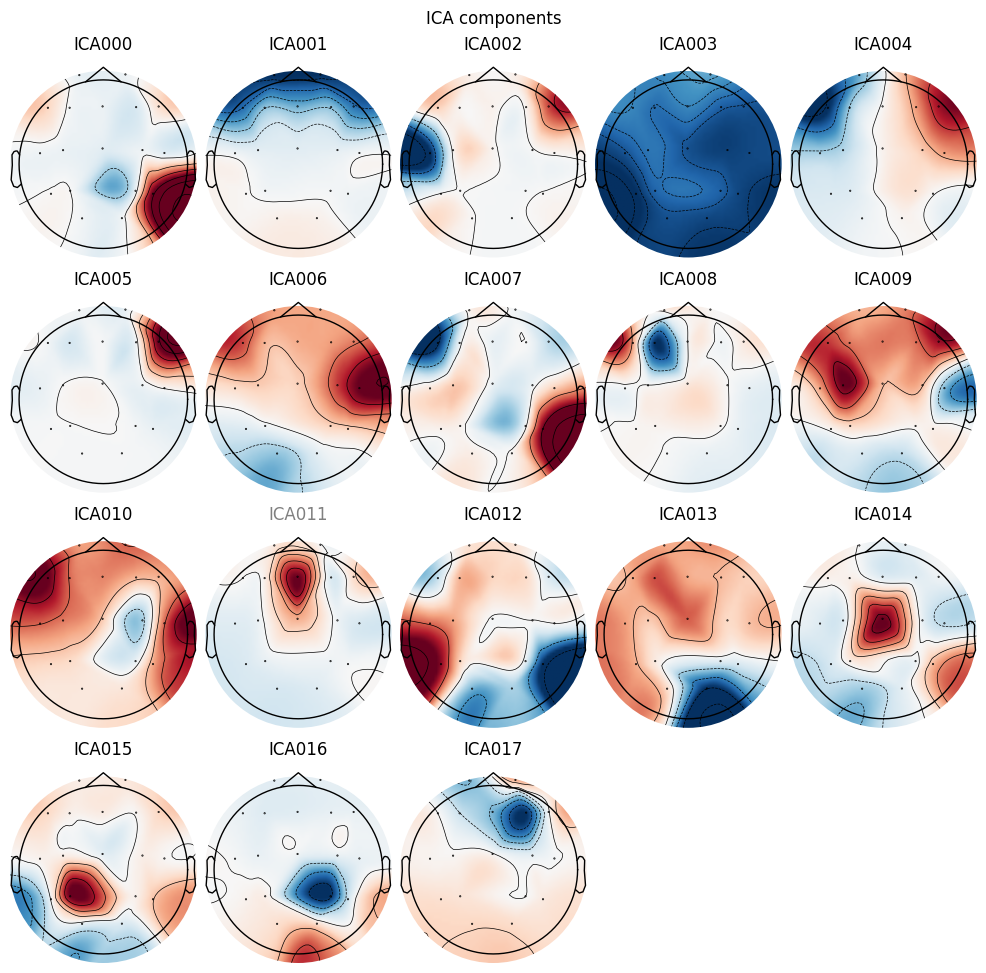

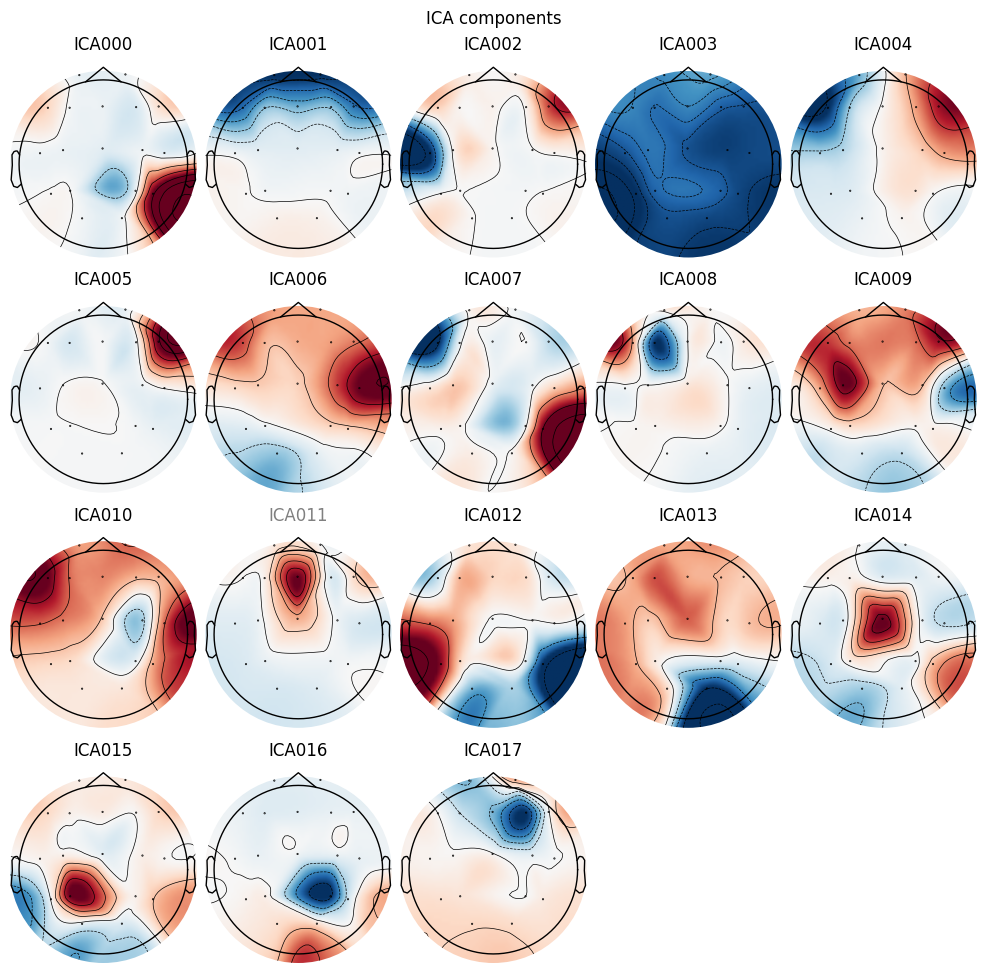

In [94]:
ica.plot_components()

In [ ]:
# TODO : Ajustez les paramètres de l'ICA et d'ICLabel
#
# Ce bloc vous permet de tester différents paramètres pour l'ICA
# (nombre de composantes, méthode) et pour ICLabel (seuils de rejet).
#
# ---
#  ATTENTION - Conséquences de vos tests :
#
# 1. MISE À JOUR DE LA FONCTION FINALE :
#    Si vous trouvez des paramètres (nb_composantes, method, seuils)
#    qui fonctionnent mieux, vous DEVEZ les reporter
#    dans la fonction finale pour qu'ils s'appliquent à tous les sujets.
#
# 2. NOM DES VARIABLES :
#    Si vous continuez le notebook avec les résultats de CE bloc,
#    utilisez les variables `ica_custom`, `raw_clean_custom`, etc.
# ---

# --- 1. Paramètres à personnaliser ---
nb_composantes = 'A_COMPLETER' # ex. 25 (un entier)
method = 'fastica' # ou 'picard' (plus lent mais souvent meilleur)
seuil_oeil = 'A_COMPLETER' # ex. 0.5 (un float, probabilité pour rejeter)
seuil_muscle = 'A_COMPLETER' # ex. 0.7 (un float, probabilité pour rejeter)

# --- 2. Entraînement de l'ICA personnalisée ---
print(f"Entraînement ICA (n={nb_composantes}, method='{method}')...")
ica_custom = mne.preprocessing.ICA(n_components=int(nb_composantes),
                                   method=method,
                                   random_state=51) # random_state pour la reproductibilité
ica_custom.fit(epochs_clean) # Entraînement sur les epochs propres (post-AutoReject)

# --- 3. Classification ICLabel ---
print("Classification des composantes avec ICLabel...")
probabilities_custom = iclabel_label_components(epochs_clean, ica_custom)

# Définition des classes (l'ordre est important et correspond à la sortie d'ICLabel)
classes = ['brain', 'muscle', 'eye', 'heart', 'line_noise', 'channel_noise', 'other']

# --- 4. Sélection des composantes à rejeter ---
# Convertir les seuils en float
f_seuil_oeil = float(seuil_oeil)
f_seuil_muscle = float(seuil_muscle)

# Trouver les index des colonnes 'eye' et 'muscle'
idx_eye = classes.index('eye')
idx_muscle = classes.index('muscle')

# Trouver les composantes (ICs) qui dépassent les seuils
eye_ICs = np.where(probas_custom[:, idx_eye] > f_seuil_oeil)[0]
muscle_ICs = np.where(probas_custom[:, idx_muscle] > f_seuil_muscle)[0]

# Combiner les listes et supprimer les doublons
# (ex: si un IC a un score > 0.7 pour 'eye' ET 'muscle')
exclude_custom = np.union1d(eye_ICs, muscle_ICs).astype(int).tolist()

print(f'\nComposantes "oeil" (seuil > {f_seuil_oeil}):', eye_ICs)
print(f'Composantes "muscle" (seuil > {f_seuil_muscle}):', muscle_ICs)
print('Liste finale des composantes à exclure:', exclude_custom)

# --- 6. Visualisation des composantes sélectionnées ---
ica_custom.exclude = exclude_custom

# Affiche les propriétés des composantes.
# Celles marquées en rouge dans la liste 'exclude_custom' seront rejetées.
# C'est une vérification visuelle essentielle pour voir si les seuils
# que vous avez choisis sont pertinents.
print("Affichage des propriétés des composantes (celles en rouge seront rejetées)...")
ica_custom.plot_properties(epochs_clean)

#### Bloc Type 3 — Pour aller plus loin
Évaluez l'impact de l'ICA sur la PSD ou les ERP, comparez avec et sans exclusion.

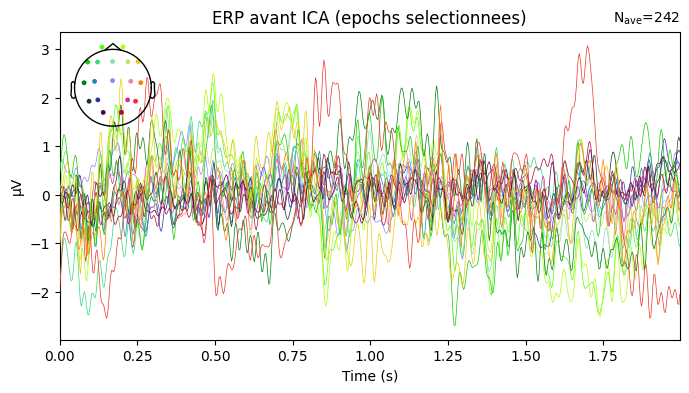

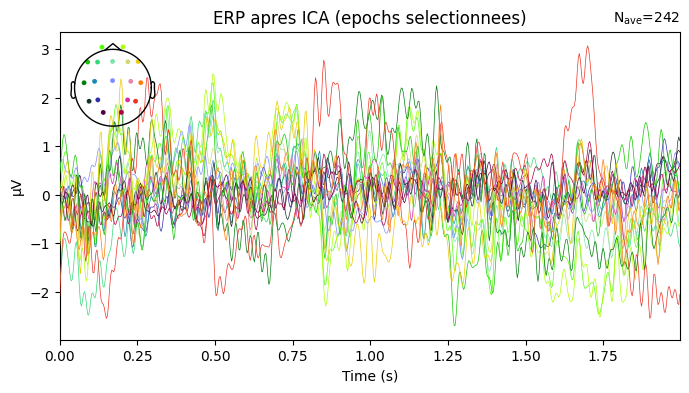

In [95]:
before = epochs_before_ica.average()
after = epochs_clean.average()

fig, ax = plt.subplots(figsize=(8, 4))
before.plot(axes=ax, show=False, spatial_colors=True)
ax.set_title('ERP avant ICA (epochs selectionnees)')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
after.plot(axes=ax, show=False, spatial_colors=True)
ax.set_title('ERP apres ICA (epochs selectionnees)')
plt.show()


### Étape 2.4 — Deuxième passe AutoReject et sauvegarde
Nous réappliquons AutoReject après ICA puis sauvegardons les données prêtes pour les analyses (Module 7).

#### Bloc Type 1 — Méthode de base
AutoReject rapide sur les epochs ICA-clean et sauvegarde au format `.fif`.

In [96]:
# Nous utilisons maintenant l'objet 'auto_reject' (qui a été 'fit' / entraîné)
# pour appliquer la transformation finale.
#
# La méthode .transform() va :
# 1. INTERPOLER les mauvais canaux sur les epochs jugées "réparables".
# 2. REJETER (supprimer) les epochs jugées "trop mauvaises" (non réparables).
#
# L'objet en entrée (ici, 'epochs_clean') doit être
# les epochs après le nettoyage ICA.
epochs_post_ica = auto_reject.transform(epochs_clean)

# Le nombre final d'epochs (première dimension) peut être inférieur
# à celui de 'epochs_clean' si .transform() a dû en rejeter.
print('Dimensions finales (epochs, canaux, temps) :', epochs_post_ica.get_data().shape)

# Définir le répertoire de sortie (convention BIDS)
out_dir = bids_path.root / 'derivatives' / 'preproc' / f'sub-{bids_path.subject}' / f'ses-{bids_path.session}' / 'eeg'

# Créer le dossier (et ses parents) s'il n'existe pas.
# exist_ok=True évite une erreur si le dossier existe déjà (essentiel)
out_dir.mkdir(parents=True, exist_ok=True)

# Construire manuellement le nom de fichier en suivant la convention BIDS
# (proc-clean = "processing clean", epo = "epochs")
out_fname = f"sub-{bids_path.subject}_ses-{bids_path.session}_task-{bids_path.task}_run-{bids_path.run}_proc-clean_epo.fif"

# Combiner le dossier et le nom de fichier
out_path = out_dir / out_fname

# Sauvegarde de l'objet 'Epochs' final au format .fif
# overwrite=True est important pour pouvoir relancer le notebook
epochs_post_ica.save(out_path, overwrite=True)
print('Epochs sauvegardées dans :', out_path)





























































































100%|██████████| Repairing epochs : 242/242 [00:01<00:00,  132.41it/s]


No bad epochs were found for your data. Returning a copy of the data you wanted to clean. Interpolation may have been done.
Dimensions finales (epochs, canaux, temps) : (242, 27, 600)
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Epochs sauvegardées dans : tasks/fivepoint/bids/derivatives/preproc/sub-01/ses-001/eeg/sub-01_ses-001_task-fivepoint_run-01_proc-clean_epo.fif


#### Bloc Type 2 — À vous de compléter
Ajoutez d'autres étapes (interpolation de canaux, égalisation des conditions) avant la sauvegarde.

In [ ]:
# TODO: inserer des etapes additionnelles avant la sauvegarde
# Exemple: interpolation de capteurs marques comme mauvais
# raw_filt.interpolate_bads(reset_bads=True)
# epochs_final = ...

# chemin_epochs_personnalise = chemin_epochs.with_name(chemin_epochs.name.replace('clean', 'custom'))
# epochs_final.save(chemin_epochs_personnalise, overwrite=True)


#### Bloc Type 3 — Pour aller plus loin
Générez un rapport MNE (`mne.Report`), calculez des métriques de qualité, documentez vos décisions (Module 5).

In [97]:
from mne.report import Report

# Initialiser l'objet Rapport avec un titre principal
report = Report(title='Fivepoint EEG — Pipeline PSY2007')

# Ajouter le signal brut (raw) au rapport
# psd=True : génère et inclut aussi un graphique de densité spectrale de puissance
report.add_raw(raw, title='Brut (avant nettoyage)', psd=True)

# Ajouter les epochs finales (nettoyées par AutoReject et ICA)
report.add_epochs(epochs_post_ica, title='Epochs nettoyées (post-AR/ICA)')

# Définir le chemin de sauvegarde du rapport
# (Nous le plaçons dans le même dossier que les epochs sauvegardées)
report_path = epochs_bids.fpath.parent / 'fivepoint_pipeline_report.html'

# Sauvegarder le rapport au format HTML
# open_browser=False : le rapport ne s'ouvrira PAS automatiquement.
report.save(report_path, overwrite=True, open_browser=False)

print('Rapport généré :', report_path)
print("\n---> IMPORTANT : Ouvrez ce fichier HTML dans votre navigateur")
print("          pour inspecter visuellement les résultats du pipeline.")

Embedding : jquery-3.6.0.min.js
Embedding : bootstrap.bundle.min.js
Embedding : bootstrap.min.css
Embedding : bootstrap-table/bootstrap-table.min.js
Embedding : bootstrap-table/bootstrap-table.min.css
Embedding : bootstrap-table/bootstrap-table-copy-rows.min.js
Embedding : bootstrap-table/bootstrap-table-export.min.js
Embedding : bootstrap-table/tableExport.min.js
Embedding : bootstrap-icons/bootstrap-icons.mne.min.css
Embedding : highlightjs/highlight.min.js
Embedding : highlightjs/atom-one-dark-reasonable.min.css
Effective window size : 6.827 (s)
Plotting power spectral density (dB=True).
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Overwriting existing file.
Saving report to : /Users/hamzaabdelhedi/Projects/Tutorials/PSY2007A2025/tasks/fivepoint/bids/derivatives/preproc/sub-01/ses-001/eeg/fivepoint_pipeline_report.html
Rapport généré : tasks/fivepoint/bids/derivatives/preproc/sub-01

## 3. Factoriser le pipeline pour tous les fichiers

Objectifs : créer des fonctions modulaires qui chargent, nettoient et sauvegardent automatiquement l'ensemble des enregistrements BIDS.

In [99]:
def pretraiter_sujet(subject, session, task, run, root_bids, 
                     l_freq=0.5, h_freq=40, notch_freqs=[60, 120]):
    """
    Applique le pipeline complet de prétraitement sur un sujet donné.
    
    Étapes :
    1. Lecture BIDS et chargement
    2. Gestion référence (Pz -> misc) et Filtrage (Notch + Passe-bande)
    3. Montage 10-20
    4. Événements et Epoching
    5. AutoReject (Fit) + Nettoyage initial
    6. ICA (Fit sur epochs propres) + ICLabel (Classification) + Rejet composantes oculaires
    7. Application ICA + AutoReject (Transform/Interpolation)
    8. Sauvegarde (Raw nettoyé, Epochs nettoyées, Rapport HTML)
    """
    
    print(f"\n{'='*40}")
    print(f"TRAITEMENT SUJET : {subject}")
    print(f"{'='*40}")

    # --- 1. Lecture des données ---
    bids_path = BIDSPath(root=root_bids, subject=subject, session=session,
                         task=task, run=run, suffix='eeg', extension='.vhdr')
    
    raw = read_raw_bids(bids_path)
    raw.load_data()

    # --- 2. Prétraitement initial (Ref + Filtres) ---
    # Gestion du canal de référence Pz (pour ne pas l'inclure dans l'analyse)
    if 'Pz' in raw.ch_names:
        raw.set_channel_types({'Pz': 'misc'})
    
    # Filtrage
    raw.notch_filter(freqs=notch_freqs)
    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin')

    # --- 3. Montage ---
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='warn')

    # --- 4. Epoching ---
    events, event_id = mne.events_from_annotations(raw)
    # Paramètres définis dans le notebook
    epochs = mne.make_fixed_length_epochs(raw_filt, duration=2.0, 
                                        overlap=0.0, preload=True)

    # --- 5. AutoReject (Fit) ---
    # On utilise AutoReject pour nettoyer les epochs AVANT l'ICA
    ar = AutoReject(random_state=42, verbose=False)
    ar.fit(epochs)
    
    reject_log = ar.get_reject_log(epochs)
    # Sélection des "bonnes" epochs pour l'entraînement ICA
    epochs_clean_for_ica = epochs[~reject_log.bad_epochs].copy()
    print(f"Epochs conservées pour fit ICA : {len(epochs_clean_for_ica)} sur {len(epochs)}")

    # --- 6. ICA et ICLabel ---
    ica = ICA(n_components=18, method='fastica', random_state=97)
    ica.fit(epochs_clean_for_ica)

    # Classification ICLabel (Correction de l'unpacking)
    probabilities = iclabel_label_components(epochs_clean_for_ica, ica)
    classes = ['brain', 'muscle', 'eye', 'line_noise', 'channel_noise', 'other']

    # Identification des composantes oculaires
    threshold_eye = 0.7
    idx_eye = class_names.index('eye')
    eye_scores = probas[:, idx_eye]
    
    # Liste des indices à exclure
    eye_components = [idx for idx, score in enumerate(eye_scores) if score >= threshold_eye]
    ica.exclude = eye_components
    print(f"Composantes oculaires exclues : {eye_components}")

    # --- 7. Application des corrections ---
    
    # A. Sur le signal continu (Raw) - optionnel mais utile
    raw_clean = ica.apply(raw.copy())
    
    # B. Sur les epochs (ICA d'abord)
    # On applique l'ICA sur le sous-ensemble d'epochs "propres" (selon la logique de vos blocs)
    epochs_ica = ica.apply(epochs_clean_for_ica.copy())
    
    # C. Application finale d'AutoReject (Interpolation)
    epochs_final = ar.transform(epochs_ica)

    # --- 8. Sauvegarde ---
    deriv_root = root_bids / 'derivatives' / 'preproc'
    
    # A. Sauvegarde Raw Clean (BIDSPath update)
    processed_bids = bids_path.copy().update(
        root=deriv_root, datatype='eeg', suffix='eeg',
        extension='.fif', processing='clean'
    )
    processed_bids.fpath.parent.mkdir(parents=True, exist_ok=True)
    raw_clean.save(processed_bids.fpath, overwrite=True)
    
    # B. Sauvegarde Epochs (Construction manuelle du chemin)
    out_dir = deriv_root / f'sub-{subject}' / f'ses-{session}' / 'eeg'
    out_dir.mkdir(parents=True, exist_ok=True)
    
    out_fname = f"sub-{subject}_ses-{session}_task-{task}_run-{run}_proc-clean_epo.fif"
    out_path = out_dir / out_fname
    epochs_final.save(out_path, overwrite=True)
    print(f"Epochs sauvegardées : {out_path}")

    # --- 9. Génération du Rapport HTML ---
    report = Report(title=f'Pipeline Report: sub-{subject}')
    report.add_raw(raw, title='Brut', psd=True)
    report.add_epochs(epochs_final, title='Epochs Nettoyées')
    
    report_path = out_dir / f"sub-{subject}_ses-{session}_pipeline_report.html"
    report.save(report_path, overwrite=True, open_browser=False)
    print(f" Rapport généré : {report_path}")

    return out_path

# ============================================================
# EXÉCUTION SUR TOUS LES SUJETS
# ============================================================

# Liste des sujets définis au début du notebook
for sub in ['01', '02', '03', '04', '05', '06', '07', '08', '10', '12', '13', '14']:
    pretraiter_sujet(sub, session=session, task=task, run=run, root_bids=root_bids)


TRAITEMENT SUJET : 01
Extracting parameters from tasks/fivepoint/bids/sub-01/ses-001/eeg/sub-01_ses-001_task-fivepoint_run-01_eeg.vhdr...
Setting channel info structure...
Reading events from tasks/fivepoint/bids/sub-01/ses-001/eeg/sub-01_ses-001_task-fivepoint_run-01_events.tsv.
Reading channel info from tasks/fivepoint/bids/sub-01/ses-001/eeg/sub-01_ses-001_task-fivepoint_run-01_channels.tsv.
Reading 0 ... 149399  =      0.000 ...   497.997 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1981 samples (6.603 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
----------------

### Bloc Type 2 — À vous de compléter
Généralisez la fonction : paramètres pour le bandpass, gestion d'erreurs (fichier manquant), ajout de logs. Utilisez les pratiques du Module 3 (fonctions) et du Module 0 (gestion de fichiers).

In [ ]:
# TODO: ameliorer la fonction pipeline
def pretraiter_sujet_custom(subject, session, task, run,
                            root, freqs_notch, bandpass, reference,
                            tmin, tmax, auto_reject_params, n_components):
    '''Completer cette fonction pour appliquer un pipeline parametrable.'''
    raise NotImplementedError('A implementer par les etudiants')

# TODO: boucle sur tous les sujets / sessions disponibles
# for subject in subjects:
#     try:
#         pretraiter_sujet_custom(...)
#     except FileNotFoundError:
#         print('Sujet', subject, 'introuvable. Verifiez la structure BIDS.')


## 3. Synthèse et prochaines étapes

Vous avez maintenant :
1. Exploré la structure BIDS et visualisé les données brutes
2. Rejoué un pipeline complet de nettoyage (filtrage, AutoReject, ICA, sauvegarde)
3. Factorisé le pipeline en fonctions réutilisables pour traiter tous les fichiers

Prochaine étape: analyse temps-fréquence ou extraction de caractéristiques (Modules 6 et 7) tout en documentant chaque paramètre pour assurer la reproductibilité. Bon travail !